# **Final Project: An Empirical Exploration of Healthcare in Nigeria**

## _Project Description_
    This project, at its most comprehensive level, provides a delineation of the voluminous array of healthcare issues/trends in the country of Nigeria. A preeminent inquiry that served as the catalyst for this analysis essentially boiled down to: "What is the most significant detrimental factor impacting life expectancy?" In addition to this, I also aim to use the following questions as general guidelines for this assay:
    
    - What are the leading causes of death in Nigeria?
    - How do certain ailments/issues vary across different demographics? 

## _Dataset Description/Dictionary_
The datasets used in this project were sourced from a [WHO (World Health Organization) site](https://data.who.int/countries/566).

"life_expec": Life expectancy at birth for men and women across 195 countries.

"men_nigeria_death_cause": Deaths per 100,000 Nigerian men, by condition name.

"regression_df" = Life expectancy rates for all Nigerians, with deaths per 100,000 Nigerians resulting from HIV, malaria, tuberculosis, and under five mortality rate.








# **Importing Datasets**

In [2]:
# Importing packages for analysis.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import statsmodels.formula.api as smf

data_path = "/Users/maduk/OneDrive/MSQE Sem 2 Python"

# Importing Life Expectancy dataset.
life_expec = pd.read_csv(os.path.join(data_path, 'life_expec.csv'))

# Importing men_nigeria_death_cause dataset.
men_nigeria_death_cause = pd.read_csv(os.path.join(data_path, 'men_nigeria_death_cause.csv'))

# Importing female_death_cause dataset.
female_death_cause =  pd.read_csv(os.path.join(data_path, 'female_death_cause.csv'))

# Importing regression dataset
regression_df = pd.read_excel(os.path.join(data_path, 'regression_data.xlsx'))

# Raw View of Data

In [4]:
regression_df.head(10)

,year,hiv_per_100k,malaria_per_100k,tuberculosis,under_five_mort,life_expec_per_100k
0,2000,1.50,413.33496,219,182.539467,54.057665
1,2001,1.40,406.09294,219,176.950351,54.473716
2,2002,1.30,393.20337,219,171.267886,54.963895
3,2003,1.30,393.80680,219,165.568083,55.584703
4,2004,1.20,402.38385,219,159.988750,56.189468
5,2005,1.20,408.65273,219,154.584512,56.917490
6,2006,1.10,411.68489,219,149.700357,57.552204
7,2007,1.00,414.04450,219,145.241030,58.177799
8,2008,0.98,415.76646,219,141.340670,58.749016
9,2009,0.92,403.54138,219,138.039216,59.301983


In [6]:
men_nigeria_death_cause.head(10)

,country_abbrv,year,condition_name,sex,amount_per_100k
0,AFG,2021,Acute hepatitis A,MLE,1.54
1,AGO,2021,Acute hepatitis A,MLE,0.06
2,ALB,2021,Acute hepatitis A,MLE,0.00
3,ARE,2021,Acute hepatitis A,MLE,0.07
4,ARG,2021,Acute hepatitis A,MLE,0.39
5,ARM,2021,Acute hepatitis A,MLE,0.02
6,ATG,2021,Acute hepatitis A,MLE,0.02
7,AUS,2021,Acute hepatitis A,MLE,0.02
8,AUT,2021,Acute hepatitis A,MLE,0.07
9,AZE,2021,Acute hepatitis A,MLE,0.01


In [8]:
female_death_cause.head(10)

,DIM_COUNTRY_CODE,DIM_YEAR_CODE,DIM_GHECAUSE_TITLE,DIM_SEX_CODE,VAL_DTHS_RATE100K_NUMERIC
0,AFG,2021,Acute hepatitis A,FMLE,1.96
1,AGO,2021,Acute hepatitis A,FMLE,0.32
2,ALB,2021,Acute hepatitis A,FMLE,0.00
3,ARE,2021,Acute hepatitis A,FMLE,0.01
4,ARG,2021,Acute hepatitis A,FMLE,0.29
5,ARM,2021,Acute hepatitis A,FMLE,0.09
6,ATG,2021,Acute hepatitis A,FMLE,0.02
7,AUS,2021,Acute hepatitis A,FMLE,0.02
8,AUT,2021,Acute hepatitis A,FMLE,0.11
9,AZE,2021,Acute hepatitis A,FMLE,0.01


In [10]:
life_expec.head(10)

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,DIM_SEX,AMOUNT_N
0,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2014,YEAR,40,COUNTRY,PUBLISHED,Life expectancy (at birth),Austria,FEMALE,83.468919
1,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2015,YEAR,40,COUNTRY,PUBLISHED,Life expectancy (at birth),Austria,FEMALE,83.286638
2,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2003,YEAR,44,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahamas,FEMALE,75.026130
3,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2005,YEAR,44,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahamas,FEMALE,75.712584
4,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2008,YEAR,44,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahamas,FEMALE,76.373527
5,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2010,YEAR,44,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahamas,FEMALE,76.058862
6,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2006,YEAR,48,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahrain,FEMALE,72.978060
7,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2012,YEAR,48,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahrain,FEMALE,75.441621
8,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2013,YEAR,48,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahrain,FEMALE,75.715421
9,90E2E48WHOSIS_000001,WHOSIS_000001,90E2E48,WHOSIS_000001,2021,YEAR,48,COUNTRY,PUBLISHED,Life expectancy (at birth),Bahrain,FEMALE,75.094661


# **Data Cleaning**

In [12]:
# Changing column names to lowercase.
life_expec.columns = life_expec.columns.str.lower()

# Drop unncessary columns.
life_expec = life_expec.drop(columns=['ind_id', 'ind_code', 'ind_uuid', 'ind_per_code', 'dim_time_type', 'dim_publish_state_code', 'ind_name'])

# Editing column names to make them more appropriate
life_expec = life_expec.rename(columns = {'dim_time' : 'year', 'dim_geo_code_m49' : 'region_level_code', 'dim_geo_code_type' : 'region_level', 'geo_name_short' : 'region_name', 'dim_sex' : 'sex', 'amount_n' : 'amount'})


In [14]:
# Set index of life_expec dataframe.
life_expec.set_index('year') 
life_expec.head(10)

,year,region_level_code,region_level,region_name,sex,amount
0,2014,40,COUNTRY,Austria,FEMALE,83.468919
1,2015,40,COUNTRY,Austria,FEMALE,83.286638
2,2003,44,COUNTRY,Bahamas,FEMALE,75.026130
3,2005,44,COUNTRY,Bahamas,FEMALE,75.712584
4,2008,44,COUNTRY,Bahamas,FEMALE,76.373527
5,2010,44,COUNTRY,Bahamas,FEMALE,76.058862
6,2006,48,COUNTRY,Bahrain,FEMALE,72.978060
7,2012,48,COUNTRY,Bahrain,FEMALE,75.441621
8,2013,48,COUNTRY,Bahrain,FEMALE,75.715421
9,2021,48,COUNTRY,Bahrain,FEMALE,75.094661


In [16]:
# Filter Male Death Dataset to include only Nigeria.
men_nigeria_death_cause = men_nigeria_death_cause[men_nigeria_death_cause['country_abbrv'] == 'NGA']
men_nigeria_death_cause.head(10)

,country_abbrv,year,condition_name,sex,amount_per_100k
120,NGA,2021,Acute hepatitis A,MLE,0.35
303,NGA,2021,Acute hepatitis B,MLE,1.45
486,NGA,2021,Acute hepatitis C,MLE,0.09
669,NGA,2021,Acute hepatitis E,MLE,0.07
852,NGA,2021,African trypanosomiasis,MLE,0.00
1035,NGA,2021,Alcohol use disorders,MLE,1.47
1218,NGA,2021,Alzheimer disease and other dementias,MLE,2.20
1401,NGA,2021,Anxiety disorders,MLE,0.00
1584,NGA,2021,Appendicitis,MLE,0.16
1767,NGA,2021,Ascariasis,MLE,0.30


In [18]:
# Renaming Female Death Dataset Columns and filtering to only include Nigeria.
female_death_cause.columns = female_death_cause.columns.str.lower()
female_death_cause = female_death_cause.rename(columns = {'dim_country_code' : 'country_abbrv', 'dim_year_code' : 'year', 'dim_ghecause_title' : 'condition_name', 'dim_sex_code' : 'sex', 'val_dths_rate100k_numeric' : 'amount_per_100k'})

female_death_cause = female_death_cause[female_death_cause['country_abbrv'] == 'NGA']
female_death_cause.head(10)

,country_abbrv,year,condition_name,sex,amount_per_100k
120,NGA,2021,Acute hepatitis A,FMLE,0.21
303,NGA,2021,Acute hepatitis B,FMLE,0.96
486,NGA,2021,Acute hepatitis C,FMLE,0.07
669,NGA,2021,Acute hepatitis E,FMLE,0.03
852,NGA,2021,African trypanosomiasis,FMLE,0.00
1035,NGA,2021,Alcohol use disorders,FMLE,0.14
1218,NGA,2021,Alzheimer disease and other dementias,FMLE,4.11
1401,NGA,2021,Anxiety disorders,FMLE,0.00
1584,NGA,2021,Appendicitis,FMLE,0.23
1767,NGA,2021,Ascariasis,FMLE,0.34


# **Summary Statistics**

##  _1) life_expec summary statistics_

In [20]:
life_expec.describe()

,year,region_level_code,amount
count,12936.000000,12936.000000,12936.000000
mean,2010.500000,453.709184,70.170890
std,6.344534,273.233973,8.799313
min,2000.000000,1.000000,36.599153
25%,2005.000000,217.000000,64.304177
50%,2010.500000,437.000000,71.736775
75%,2016.000000,691.000000,77.006768
max,2021.000000,958.000000,87.371027


In [22]:
men_nigeria_death_cause.describe()

,year,amount_per_100k
count,134.0,134.000000
mean,2021.0,5.563507
std,0.0,14.942938
min,2021.0,0.000000
25%,2021.0,0.000000
50%,2021.0,0.475000
75%,2021.0,2.777500
max,2021.0,95.890000


In [24]:
regression_df.describe()

,year,hiv_per_100k,malaria_per_100k,tuberculosis,under_five_mort,life_expec_per_100k
count,23.00000,23.000000,23.000000,23.0,23.000000,22.000000
mean,2011.00000,0.862174,353.912352,219.0,138.378470,59.415549
std,6.78233,0.338082,50.558140,0.0,21.542053,3.016052
min,2000.00000,0.390000,294.110660,219.0,107.172797,54.057665
25%,2005.50000,0.560000,303.606240,219.0,123.437761,57.076169
50%,2011.00000,0.850000,351.645060,219.0,132.905149,59.993057
75%,2016.50000,1.150000,404.817160,219.0,152.142435,61.969656
max,2022.00000,1.500000,415.766460,219.0,182.539467,63.397498


In [26]:
female_death_cause.describe()

,year,amount_per_100k
count,134.0,134.000000
mean,2021.0,5.051119
std,0.0,13.760508
min,2021.0,0.000000
25%,2021.0,0.000000
50%,2021.0,0.445000
75%,2021.0,2.190000
max,2021.0,83.500000


# **Graphical Analysis**

## _Plot 1: Life Expectancy at Birth by Gender_

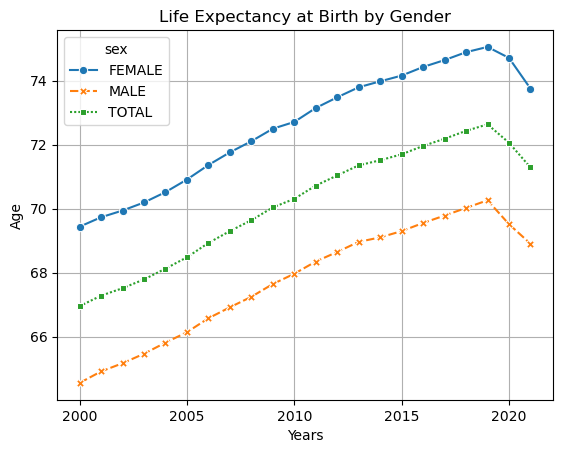

In [28]:
ax = sns.lineplot(
    data = life_expec,
    x = 'year',
    y = 'amount',
    hue = 'sex',
markers = True, style = 'sex', errorbar = None)


ax.set_title("Life Expectancy at Birth by Gender")
ax.set_xlabel("Years")
ax.set_ylabel("Age")
ax.grid()

- Plot shows Nigerian women on average have a slightly higher life expectancy of roughly 5 years.

## _Plot 2: Life Expectancy at Birth by Region_

In [30]:
# Filter data to include Global, Africa (WHO Region), and Nigeria
filtered_life_expect = life_expec[
    ((life_expec['region_level'] == 'GLOBAL') & (life_expec['region_name'] == 'World')) |
    ((life_expec['region_level'] == 'WHOREGION') & (life_expec['region_name'] == 'Africa')) |
    ((life_expec['region_level'] == 'COUNTRY') & (life_expec['region_name'] == 'Nigeria'))
]

# Use only total population, not by sex
filtered_life_expect = filtered_life_expect[filtered_life_expect['sex'] == 'TOTAL']

# Reset index
filtered_life_expect = filtered_life_expect.reset_index()

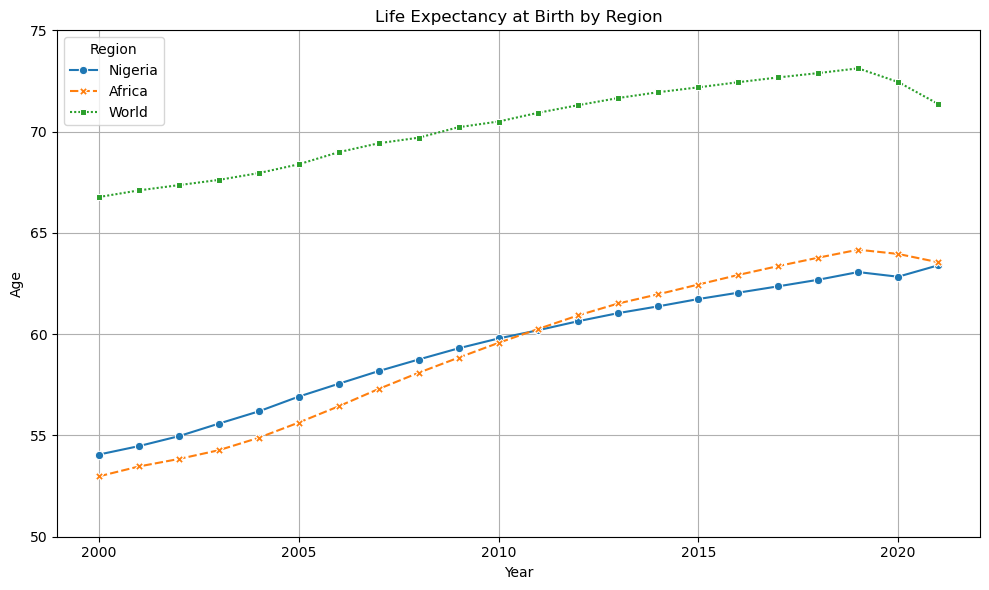

In [32]:
# Plotting Lineplot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=filtered_life_expect,
    x='year',
    y='amount',
    hue='region_name',
    style='region_name',
    markers= True,
    dashes=True
)

ax.set_title("Life Expectancy at Birth by Region")
ax.set_xlabel("Year")
ax.set_ylabel("Age")
ax.set_ylim(50, 75)  # Optional: to match WHO y-axis scale
ax.grid(True)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

- Up to 2010, Nigeria's total life expectancy was consistnently slightly above that of the continental average.
- Life expectancy has improved roughly 10 years from 2000-2021  

## _Plot 3: Common Causes of Death (MEN)_

In [34]:
# Filter for 2021, men only
deaths_men = men_nigeria_death_cause[
(men_nigeria_death_cause['sex'] == 'MLE') &
(men_nigeria_death_cause['year'] == 2021)
]

# Get top 10 cases of death by amount
top_10_men = deaths_men.sort_values(by= 'amount_per_100k', ascending =False).head(10)

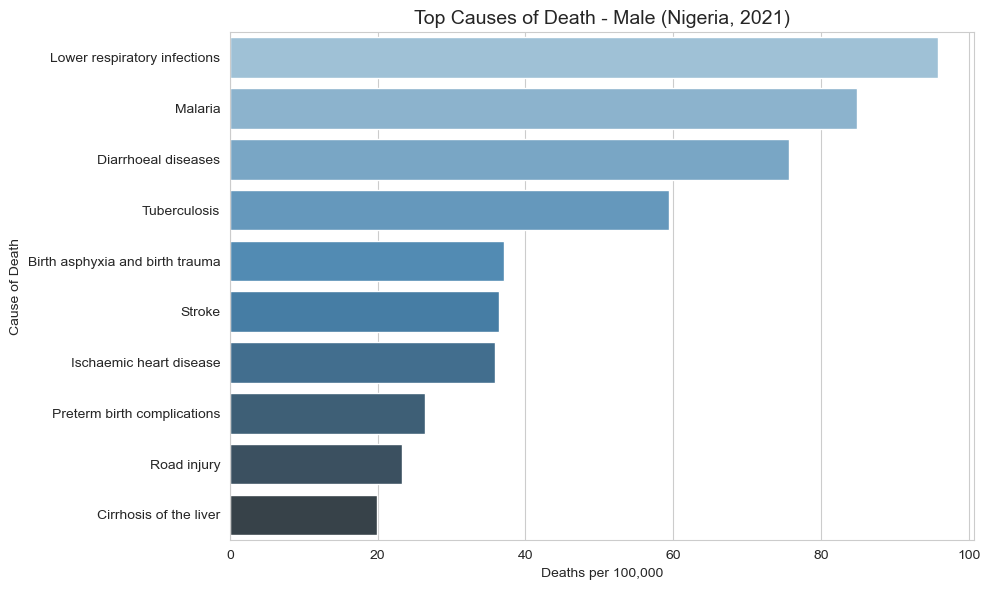

In [36]:
# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=top_10_men,
    y='condition_name',
    x='amount_per_100k',
    palette='Blues_d',
    hue = 'condition_name'
)

ax.set_title("Top Causes of Death - Male (Nigeria, 2021)", fontsize=14)
ax.set_xlabel("Deaths per 100,000")
ax.set_ylabel("Cause of Death")
plt.tight_layout()
plt.show()

- Lower Respiratory, Malaria, Diarrhoeal account for the top 3 largest proportions of deaths in Nigerian men.

## _Plot 4: Common Causes of Death (WOMEN)_

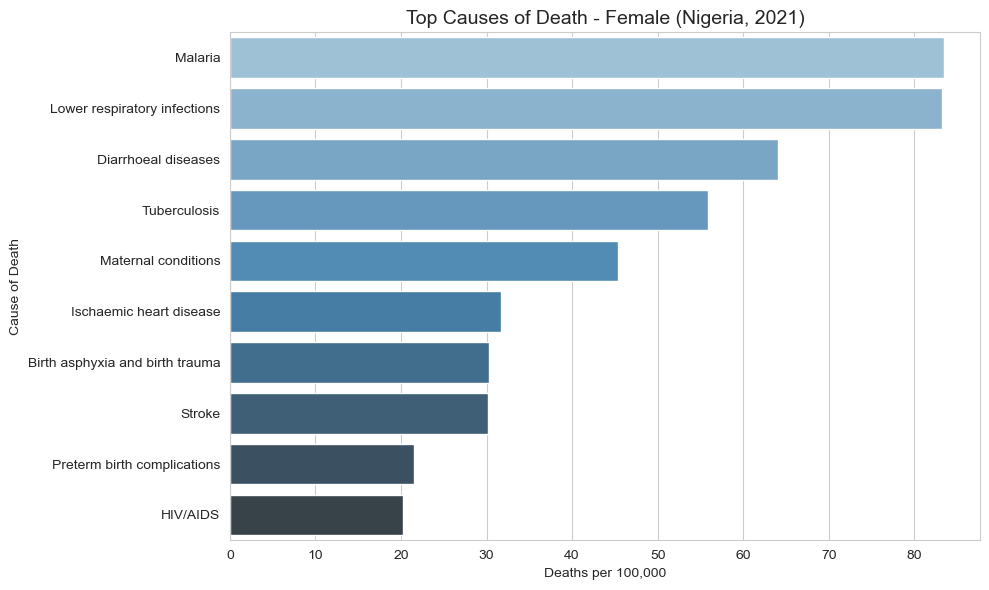

In [38]:
# Filter for 2021, wommen only
deaths_women = female_death_cause[
(female_death_cause['sex'] == 'FMLE') &
(female_death_cause['year'] == 2021)
]

# Get top 10 cases of death by amount
top_10_women = deaths_women.sort_values(by= 'amount_per_100k', ascending =False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=top_10_women,
    y='condition_name',
    x='amount_per_100k',
    palette='Blues_d',
    hue = 'condition_name'
)

ax.set_title("Top Causes of Death - Female (Nigeria, 2021)", fontsize=14)
ax.set_xlabel("Deaths per 100,000")
ax.set_ylabel("Cause of Death")
plt.tight_layout()
plt.show()

- Malaria, Lower Respiratory, Diarrhoeal are the top 3 significant causes of death for Nigerian Females.

# Regression Analysis

In [40]:
# Simple linear regression to test significant indicators of life expectancy
mdl_linear = smf.ols("life_expec_per_100k ~  hiv_per_100k + malaria_per_100k + tuberculosis + under_five_mort", data = regression_df).fit()
mdl_linear.summary(slim = True)

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     life_expec_per_100k   R-squared:                       0.996
Model:                             OLS   Adj. R-squared:                  0.995
No. Observations:                   22   F-statistic:                     1539.
Covariance Type:             nonrobust   Prob (F-statistic):           7.05e-22
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0016   4.51e-05     35.420      0.000       0.002       0.002
hiv_per_100k        -2.5879      1.507     -1.717      0.103      -5.754       0.578
malaria_per_100k    -0.0063      0.003     -2.179      0.043      -0.012      -0.000
tuberculosis         0.3498      0.010     35.420      0.000       0.329       0.371
under_five_mort     -0.0904      0.019     -4.798      0.000      -0.130      -0.051
====================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.1e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

- While magnitude is not very high, signage is approprite (except for tuberculosis)
- We can say that all else being equal an increase in malaria prevalence linearly predicts a decrease in overall life expec.
- This finding while not causal is significant at 5% level.